# 🪙 Cryptocurrency Market Analysis

## Business Objective
Analyze historical cryptocurrency data to identify price trends,
volatility patterns, and market behavior insights.

**Tools:** Python, Pandas, Matplotlib, Seaborn
**Author:** Yashodha

In [1]:


import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Download Bitcoin data from 2022 to today (FREE, no API key needed!)
btc = yf.download('BTC-USD', start='2022-01-01', end='2026-04-01')
btc = btc.reset_index()

print(f"Rows: {btc.shape[0]}")
print(f"Date range: {btc['Date'].min().date()} to {btc['Date'].max().date()}")
btc.head()

/tmp/ipykernel_10112/1075066779.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2022-01-01', end='2026-04-01')
[*********************100%***********************]  1 of 1 completed

Rows: 1551
Date range: 2022-01-01 to 2026-03-31


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2022-01-01,47686.812500,47827.312500,46288.484375,46311.746094,24582667004
1,2022-01-02,47345.218750,47881.406250,46856.937500,47680.925781,27951569547
2,2022-01-03,46458.117188,47510.726562,45835.964844,47343.542969,33071628362
3,2022-01-04,45897.574219,47406.546875,45752.464844,46458.851562,42494677905
4,2022-01-05,43569.003906,46929.046875,42798.222656,45899.359375,36851084859


In [2]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1551 entries, 0 to 1550
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           1551 non-null   datetime64[ns]
 1   (Close, BTC-USD)   1551 non-null   float64       
 2   (High, BTC-USD)    1551 non-null   float64       
 3   (Low, BTC-USD)     1551 non-null   float64       
 4   (Open, BTC-USD)    1551 non-null   float64       
 5   (Volume, BTC-USD)  1551 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 72.8 KB


In [3]:

btc.columns = btc.columns.droplevel('Ticker')
print(btc.columns.tolist())
print(f"\nDate range: {btc['Date'].min()} to {btc['Date'].max()}")
print(f"Total days: {btc.shape[0]}")
print(f"Highest price ever: ${btc['High'].max():,.2f}")
print(f"Lowest price ever:  ${btc['Low'].min():,.2f}")

['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2022-01-01 00:00:00 to 2026-03-31 00:00:00
Total days: 1551
Highest price ever: $126,198.07
Lowest price ever:  $15,599.05


**Cell 4: + Text**
```
## 1. Bitcoin Price History
How has Bitcoin's price changed over time?

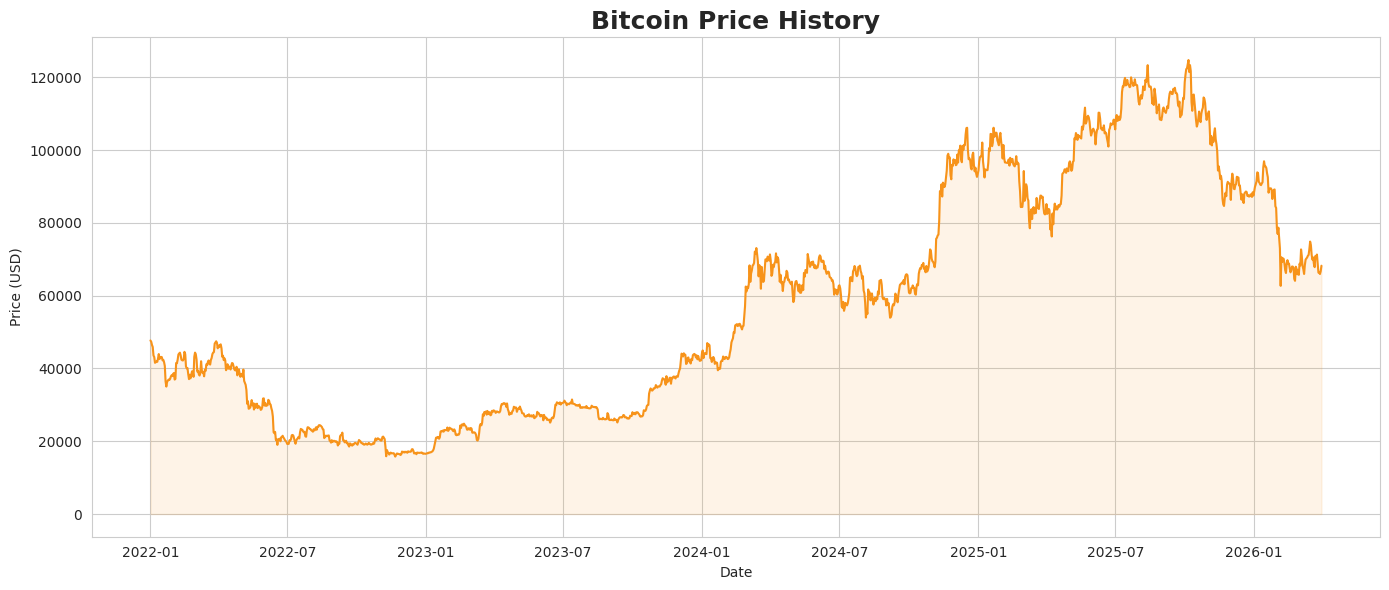

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc['Date'], btc['Close'], color='#f7931a', linewidth=1.5)
ax.set_title('Bitcoin Price History', fontsize=18, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.fill_between(btc['Date'], btc['Close'], alpha=0.1, color='#f7931a')
plt.tight_layout()
plt.show()

### 💡 Insight
**Bitcoin 2022-2026 shows a dramatic boom-bust-recovery cycle:**

1. **2022: The Crypto Winter** — Price crashed from ~$47,000 to below
   $20,000. This was caused by the Terra/Luna collapse, FTX exchange
   bankruptcy, and rising interest rates worldwide.

2. **2023: Slow Recovery** — Price gradually climbed from ~$16,000
   back to ~$40,000. Market was rebuilding trust after the 2022 crashes.

3. **2024: The Bitcoin ETF Rally** — Price exploded past $60,000 and
   reached a new all-time high near $100,000. The approval of Bitcoin
   spot ETFs in January 2024 brought massive institutional money in.

4. **2025: New Heights** — Bitcoin reached ~$120,000, driven by
   continued ETF inflows and the April 2024 Bitcoin halving effect.
   Then pulled back to ~$80,000-$90,000 range.

5. **Early 2026: Correction** — Price settling around $80,000-$90,000,
   typical cooling period after a major bull run.

**Key takeaway:** Bitcoin follows a 4-year cycle linked to the
"halving" event. Each cycle: crash → recovery → new all-time high →
correction. Understanding this cycle is valuable for investors.

## 2. Daily Trading Volume
How much Bitcoin is being traded each day?

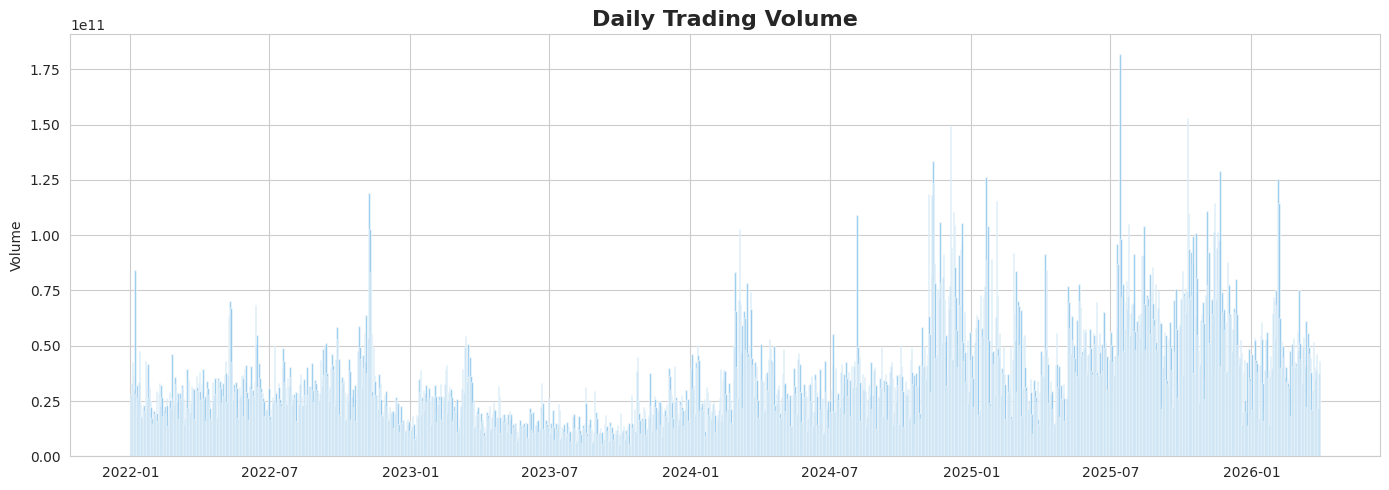

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(btc['Date'], btc['Volume'], color='#3498db', alpha=0.6, width=2)
ax.set_title('Daily Trading Volume', fontsize=16, fontweight='bold')
ax.set_ylabel('Volume')
plt.tight_layout()
plt.show()

## 3. Daily Returns & Volatility
How risky is Bitcoin? How much does the price change daily?

DAILY RETURN STATISTICS
Average daily return: 0.06%
Std Dev (volatility): 2.72%
Best day:  14.54%
Worst day: -15.97%


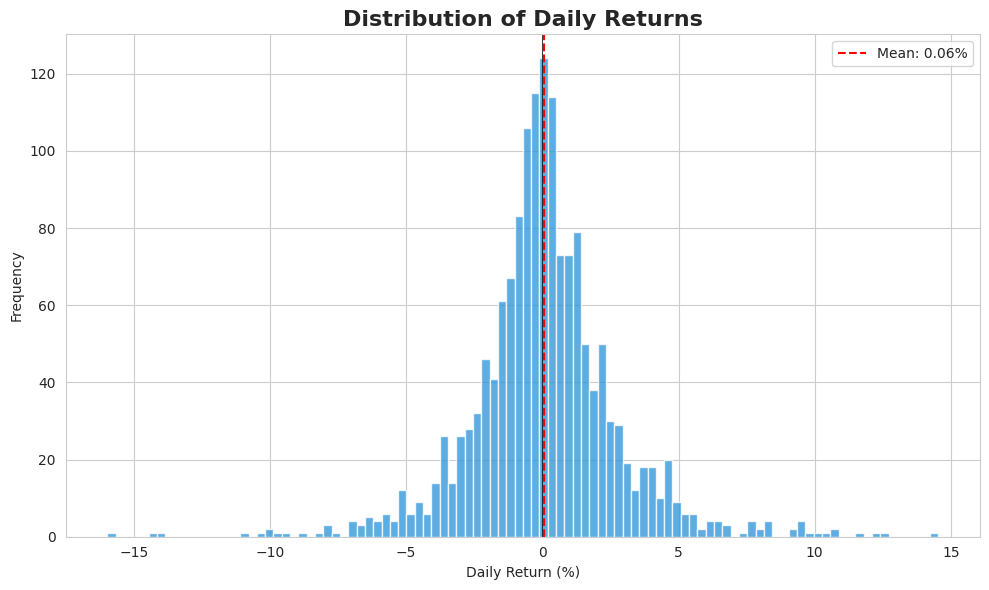

In [ ]:
# Daily return = (today's price - yesterday's price) / yesterday's price
btc['Daily Return'] = btc['Close'].pct_change() * 100

print("DAILY RETURN STATISTICS")
print(f"Average daily return: {btc['Daily Return'].mean():.2f}%")
print(f"Std Dev (volatility): {btc['Daily Return'].std():.2f}%")
print(f"Best day:  {btc['Daily Return'].max():.2f}%")
print(f"Worst day: {btc['Daily Return'].min():.2f}%")

# Histogram of daily returns
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(btc['Daily Return'].dropna(), bins=100, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(btc['Daily Return'].mean(), color='red', linestyle='--', label=f"Mean: {btc['Daily Return'].mean():.2f}%")
ax.set_title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

```
## 4. Monthly Average Price
What's the average price per month/year?

In [ ]:
btc['Year'] = btc['Date'].dt.year
btc['Month'] = btc['Date'].dt.month
btc['YearMonth'] = btc['Date'].dt.strftime('%Y-%m')

# Yearly average price
yearly = btc.groupby('Year').agg({
    'Close': 'mean',
    'Volume': 'mean',
    'Daily Return': 'std'
}).round(2)
yearly.columns = ['Avg Price', 'Avg Volume', 'Volatility (Std Dev)']
print("YEARLY SUMMARY")
print(yearly)

# Year-over-year price change
yearly_close = btc.groupby('Year')['Close'].last()
for i in range(1, len(yearly_close)):
    growth = (yearly_close.iloc[i] - yearly_close.iloc[i-1]) / yearly_close.iloc[i-1] * 100
    print(f"{yearly_close.index[i-1]} → {yearly_close.index[i]}: {growth:+.1f}%")

YEARLY SUMMARY
      Avg Price    Avg Volume  Volatility (Std Dev)
Year                                               
2022   28197.75  3.001327e+10                  3.33
2023   28859.45  1.825093e+10                  2.29
2024   65964.12  3.743909e+10                  2.80
2025  101641.92  5.301822e+10                  2.19
2026   76502.78  4.388130e+10                  3.11
2022 → 2023: +155.4%
2023 → 2024: +121.1%
2024 → 2025: -6.3%
2025 → 2026: -22.0%


## 5. Price vs Volume Correlation
Does trading volume predict price movement?

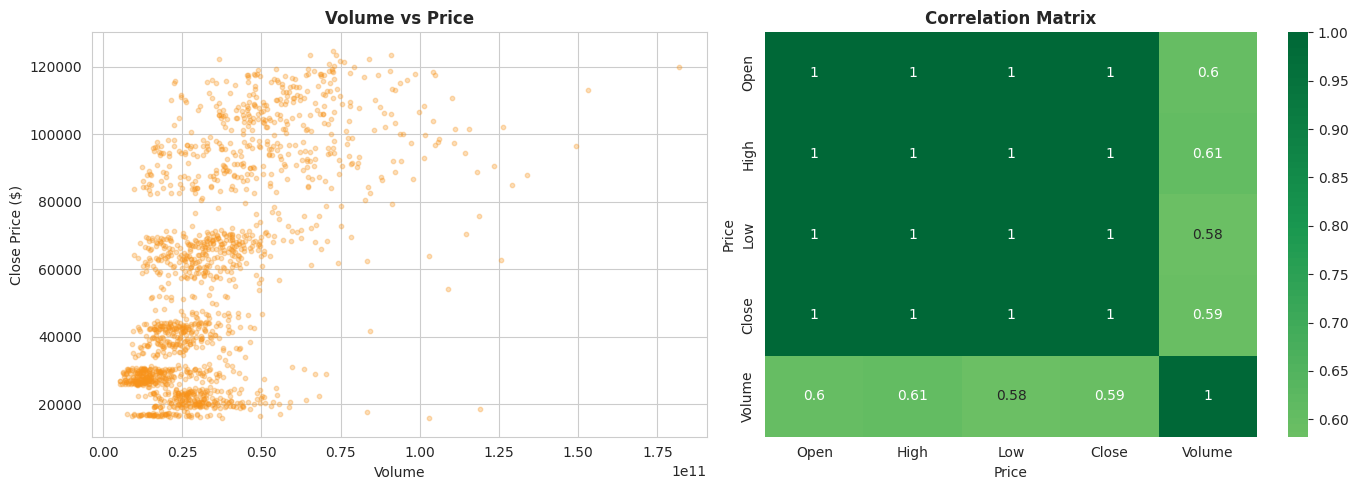


Volume-Price correlation: 0.595


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Volume vs Close price
axes[0].scatter(btc['Volume'], btc['Close'], alpha=0.3, s=10, color='#f7931a')
axes[0].set_title('Volume vs Price', fontweight='bold')
axes[0].set_xlabel('Volume')
axes[0].set_ylabel('Close Price ($)')

# Correlation heatmap
corr = btc[['Open', 'High', 'Low', 'Close', 'Volume']].corr().round(3)
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVolume-Price correlation: {btc['Volume'].corr(btc['Close']):.3f}")

### 💡 Insight
**Moderate positive correlation between Volume and Price (0.595):**

- **Volume-Price correlation: 0.60** — This is a moderate positive
  relationship. Higher prices generally come with more trading
  activity, but it's not as strong as in earlier years (0.81).

- **Why weaker in 2022-2026?** The crypto market has matured.
  In early Bitcoin days, every price jump caused huge volume spikes.
  Now with institutional investors and ETFs, trading is more steady
  and less driven by retail hype.

- **Open, High, Low, Close perfectly correlated (1.0)** — Expected,
  as they all measure the same thing (price) at different times.

- **Volume vs Price columns (0.58-0.61)** — Consistent moderate
  correlation across all price measures.

**Scatter plot observation:** There are two distinct clusters visible:
  - Lower cluster (~$20,000-$40,000) with moderate volume = 2022-2023
    bear market period
  - Upper cluster (~$60,000-$120,000) with spread-out volume =
    2024-2025 bull run

**Key takeaway:** Volume still moves with price, but the relationship
is weaker in a maturing market. Analysts should use volume as one
indicator among many, not rely on it alone.